# Spain National PV Generation — ESIOS Data Assembly

Loads the three manually-exported ESIOS CSV files (one per year) and assembles them into a single clean hourly generation series.

**Source:** REE ESIOS — Indicator 1295 *Real time generation Solar PV* (MW)

**Note on units:** ESIOS indicator 1295 reports instantaneous power in **MW**. For an hourly time series MW ≈ MWh/h, so we treat each value as the energy produced in that hour (MWh). This is the same convention used by ESIOS exports.

**Period:** 2023-01-01 → 2025-12-31 (UTC)

**Output:** `spain_total/data/spain_pv_generation.csv`

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Ensure working directory is spain_total/ regardless of where VSCode launched the kernel
nb_dir = os.path.abspath(os.path.dirname('spain_total/1_generation_download.ipynb'))
if os.path.basename(os.getcwd()) != 'spain_total':
    candidate = os.path.join(os.getcwd(), 'spain_total')
    if os.path.isdir(candidate):
        os.chdir(candidate)
print(f'Working directory: {os.getcwd()}')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

Working directory: c:\Users\nicol\Documents\ML-solar-forecast\spain_total


In [2]:
DATA_DIR    = 'data'
OUTPUT_FILE = os.path.join(DATA_DIR, 'spain_pv_generation.csv')

# Locate all ESIOS export files in data dir
esios_files = sorted(glob.glob(os.path.join(DATA_DIR, 'export_RealTimeGenerationSolarPV*.csv')))
print(f'Found {len(esios_files)} ESIOS files:')
for f in esios_files:
    print(f'  {os.path.basename(f)}')

Found 3 ESIOS files:
  export_RealTimeGenerationSolarPV_2026-03-14_20_54.csv
  export_RealTimeGenerationSolarPV_2026-03-14_20_55 (1).csv
  export_RealTimeGenerationSolarPV_2026-03-14_20_55.csv


## 1. Load and concatenate the three annual files

In [3]:
def load_esios_csv(path: str) -> pd.DataFrame:
    """Load a single ESIOS semicolon-separated export. Returns UTC-indexed DataFrame."""
    df = pd.read_csv(path, sep=';')
    df = df[['datetime', 'value']].rename(columns={'value': 'pv_generation_mwh'})

    # ESIOS timestamps are CET/CEST with explicit UTC offset — convert to UTC
    df['datetime_utc'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_localize(None)
    df = df[['datetime_utc', 'pv_generation_mwh']].sort_values('datetime_utc').reset_index(drop=True)
    return df


frames = []
for path in esios_files:
    df = load_esios_csv(path)
    print(f'{os.path.basename(path):55s}  {len(df):5d} rows  '
          f'{df["datetime_utc"].min()} -> {df["datetime_utc"].max()}')
    frames.append(df)

generation = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows (before dedup): {len(generation)}')

export_RealTimeGenerationSolarPV_2026-03-14_20_54.csv     8760 rows  2022-12-31 23:00:00 -> 2023-12-31 22:00:00
export_RealTimeGenerationSolarPV_2026-03-14_20_55 (1).csv   8760 rows  2024-12-31 23:00:00 -> 2025-12-31 22:00:00
export_RealTimeGenerationSolarPV_2026-03-14_20_55.csv     8784 rows  2023-12-31 23:00:00 -> 2024-12-31 22:00:00

Total rows (before dedup): 26304


## 2. Deduplicate & validate coverage

In [4]:
n_before = len(generation)
generation = generation.drop_duplicates(subset='datetime_utc').sort_values('datetime_utc').reset_index(drop=True)
print(f'Duplicates removed: {n_before - len(generation)}')

# Expected hourly range in UTC: 2023-01-01 00:00 → 2025-12-31 23:00
# (Spain is UTC+1 in winter, so 2023-01-01T00:00+01:00 = 2022-12-31T23:00 UTC
#  — we trim to our target window below)
TARGET_START = '2023-01-01 00:00:00'
TARGET_END   = '2025-12-31 23:00:00'

generation = generation[
    (generation['datetime_utc'] >= TARGET_START) &
    (generation['datetime_utc'] <= TARGET_END)
].reset_index(drop=True)

expected_idx = pd.date_range(TARGET_START, TARGET_END, freq='h')
actual_idx   = pd.DatetimeIndex(generation['datetime_utc'])

missing_ts = expected_idx.difference(actual_idx)
print(f'\nRows after trimming to target window : {len(generation)}')
print(f'Expected rows (26304)               : {len(expected_idx)}')
print(f'Missing timestamps                  : {len(missing_ts)}')

if len(missing_ts) > 0:
    print('\nFirst 20 missing:')
    print(missing_ts[:20].tolist())

Duplicates removed: 0

Rows after trimming to target window : 26303
Expected rows (26304)               : 26304
Missing timestamps                  : 1

First 20 missing:
[Timestamp('2025-12-31 23:00:00')]


## 3. Sanity checks

In [5]:
print('=== Generation statistics (MWh/h) ===')
print(generation['pv_generation_mwh'].describe().round(1))

# Spain national PV installed capacity:
#   2023 ~18 GW, 2024 ~23 GW, 2025 ~28 GW
# Expected summer peak: 15,000–22,000 MWh/h
max_val = generation['pv_generation_mwh'].max()
print(f'\nMax hourly output  : {max_val:,.0f} MWh  ({max_val/1000:.1f} GWh/h)')

n_negative = (generation['pv_generation_mwh'] < 0).sum()
n_over_cap  = (generation['pv_generation_mwh'] > 35_000).sum()
print(f'Negative values    : {n_negative}')
print(f'Values > 35,000 MWh: {n_over_cap}')

=== Generation statistics (MWh/h) ===
count    26303.0
mean      4876.1
std       6155.1
min          0.0
25%         32.0
50%        337.1
75%      10257.0
max      22758.9
Name: pv_generation_mwh, dtype: float64

Max hourly output  : 22,759 MWh  (22.8 GWh/h)
Negative values    : 0
Values > 35,000 MWh: 0


In [6]:
# Monthly totals pivot — expected ~2,500–7,000 GWh/month for Spain PV
gen_indexed = generation.set_index('datetime_utc')

monthly = (
    gen_indexed['pv_generation_mwh']
    .resample('ME')
    .sum()
    .rename('monthly_gwh')
    .div(1000)
    .round(1)
)

pivot = monthly.to_frame()
pivot['year']  = pivot.index.year
pivot['month'] = pivot.index.month
pivot = pivot.pivot(index='month', columns='year', values='monthly_gwh')
pivot.index = [f'M{m:02d}' for m in pivot.index]

print('Monthly generation totals (GWh):')
print(pivot.to_string())

annual = monthly.groupby(monthly.index.year).sum()
print(f'\nAnnual totals (GWh):')
print(annual.to_string())
# Reference: Spain solar PV ~ 34 TWh (2023), ~40 TWh (2024)

Monthly generation totals (GWh):
year    2023    2024    2025
M01   1606.1  1836.3  2196.0
M02   2020.5  2448.8  3072.8
M03   2939.9  2927.0  2942.4
M04   3623.0  3865.6  3886.7
M05   3739.5  5033.5  4737.0
M06   3778.3  4652.0  5885.4
M07   4437.0  5766.4  6166.5
M08   4318.3  5291.8  5744.3
M09   3227.6  4114.1  4956.0
M10   2464.7  2696.8  3998.9
M11   1886.4  2254.0  3079.4
M12   1766.6  2384.2  2512.9

Annual totals (GWh):
datetime_utc
2023    35807.9
2024    43270.5
2025    49178.3


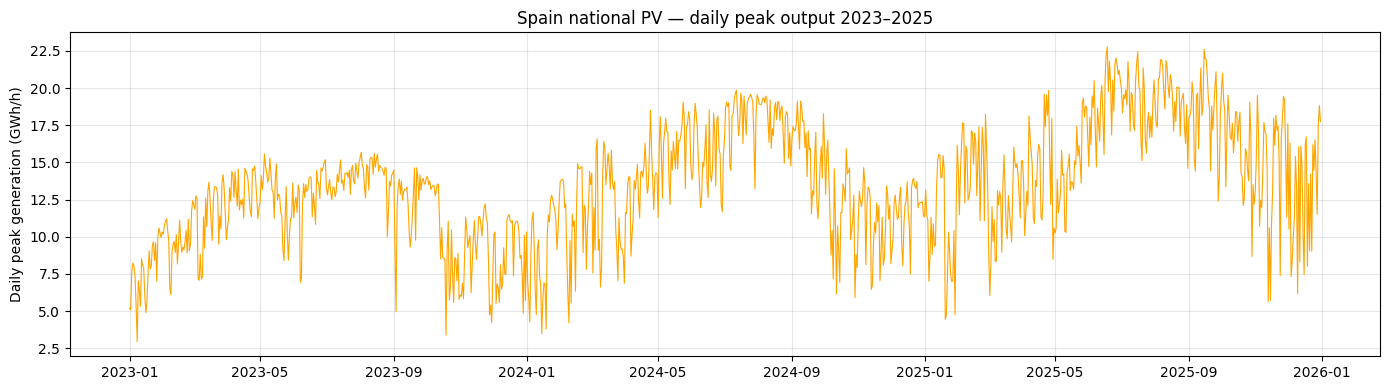

In [7]:
# Plot daily max per month to visually verify seasonal pattern
daily_max = gen_indexed['pv_generation_mwh'].resample('D').max()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_max.index, daily_max.values / 1000, lw=0.8, color='orange')
ax.set_ylabel('Daily peak generation (GWh/h)')
ax.set_title('Spain national PV — daily peak output 2023–2025')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Export

In [8]:
generation.set_index('datetime_utc').to_csv(OUTPUT_FILE)
print(f'Saved: {OUTPUT_FILE}')
print(f'Shape: {generation.shape}')
generation.head()

Saved: data\spain_pv_generation.csv
Shape: (26303, 2)


,datetime_utc,pv_generation_mwh
0,2023-01-01 00:00:00,19.583333
1,2023-01-01 01:00:00,19.666667
2,2023-01-01 02:00:00,19.333333
3,2023-01-01 03:00:00,19.833333
4,2023-01-01 04:00:00,18.833333


## Summary

| Field | Value |
|---|---|
| **Source** | REE ESIOS manual export |
| **Indicator** | 1295 — Real time generation Solar PV |
| **Unit** | MW (treated as MWh/h for hourly series) |
| **Timezone** | UTC (converted from CET/CEST source) |
| **Period** | 2023-01-01 → 2025-12-31 |
| **Output** | `spain_total/data/spain_pv_generation.csv` |

**Next step:** `2_data_assembly.ipynb` — load ERA5 per plant, run pvlib clearsky, disaggregate this national total to per-plant targets using pvlib-weighted proportional allocation.